In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/turkey_final_bayesian_model.csv')

# Convert the Date column to datetime objects to ensure proper time-series handling
df['Date'] = pd.to_datetime(df['Date'])

# Sort the entire dataset chronologically to establish a strict timeline
df = df.sort_values(by='Date').reset_index(drop=True)

# Isolate matches for a specific team playing at home to inspect their timeline
team_name = 'Fenerbahce'
team_df = df[df['HomeTeam'] == team_name].copy()

# Calculate the cumulative number of home wins prior to the current match
# The shift function ensures the result of the current match is hidden from the calculation
team_df['past_home_wins'] = team_df['h win'].shift(1).cumsum().fillna(0)

# Calculate the cumulative number of home matches played prior to the current match
team_df['past_home_games'] = team_df['h win'].shift(1).expanding().count().fillna(0)

# Calculate the expected historical win rate based strictly on past observations
# Multiplied by 100 to match the percentage format used in the dataset
team_df['manual_h_win_rt'] = (team_df['past_home_wins'] / team_df['past_home_games']) * 100

# Handle division by zero for the very first match where no past data exists
team_df['manual_h_win_rt'] = team_df['manual_h_win_rt'].fillna(0)

# Calculate a rolling discrepancy to easily spot any data leakage
team_df['leakage_difference'] = team_df['h win rt'] - team_df['manual_h_win_rt']

# Select relevant columns to visually inspect the timeline
columns_to_inspect = [
    'Date',
    'HomeTeam',
    'h win',
    'h p',
    'h win rt',
    'manual_h_win_rt',
    'leakage_difference'
]

# Display the first 15 home matches for the selected team
verification_table = team_df[columns_to_inspect].head(15)
print(verification_table)

          Date    HomeTeam  h win  h p   h win rt  manual_h_win_rt  \
19  2020-09-21  Fenerbahce      0    1  68.085106         0.000000   
35  2020-10-03  Fenerbahce      1    3  68.085106         0.000000   
53  2020-10-25  Fenerbahce      1    3  68.085106        50.000000   
69  2020-11-07  Fenerbahce      0    0  68.085106        66.666667   
94  2020-11-29  Fenerbahce      0    0  68.085106        50.000000   
110 2020-12-12  Fenerbahce      0    0  68.085106        40.000000   
134 2020-12-23  Fenerbahce      1    3  68.085106        33.333333   
169 2021-01-07  Fenerbahce      1    3  68.085106        42.857143   
188 2021-01-18  Fenerbahce      1    3  68.085106        50.000000   
209 2021-01-25  Fenerbahce      1    3  68.085106        55.555556   
213 2021-01-30  Fenerbahce      1    3  68.085106        60.000000   
233 2021-02-06  Fenerbahce      0    0  68.085106        63.636364   
255 2021-02-21  Fenerbahce      0    0  68.085106        58.333333   
279 2021-03-04  Fene

/tmp/ipykernel_2647/4251640245.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcomes, y=percentages, ax=axes[0], palette='viridis')


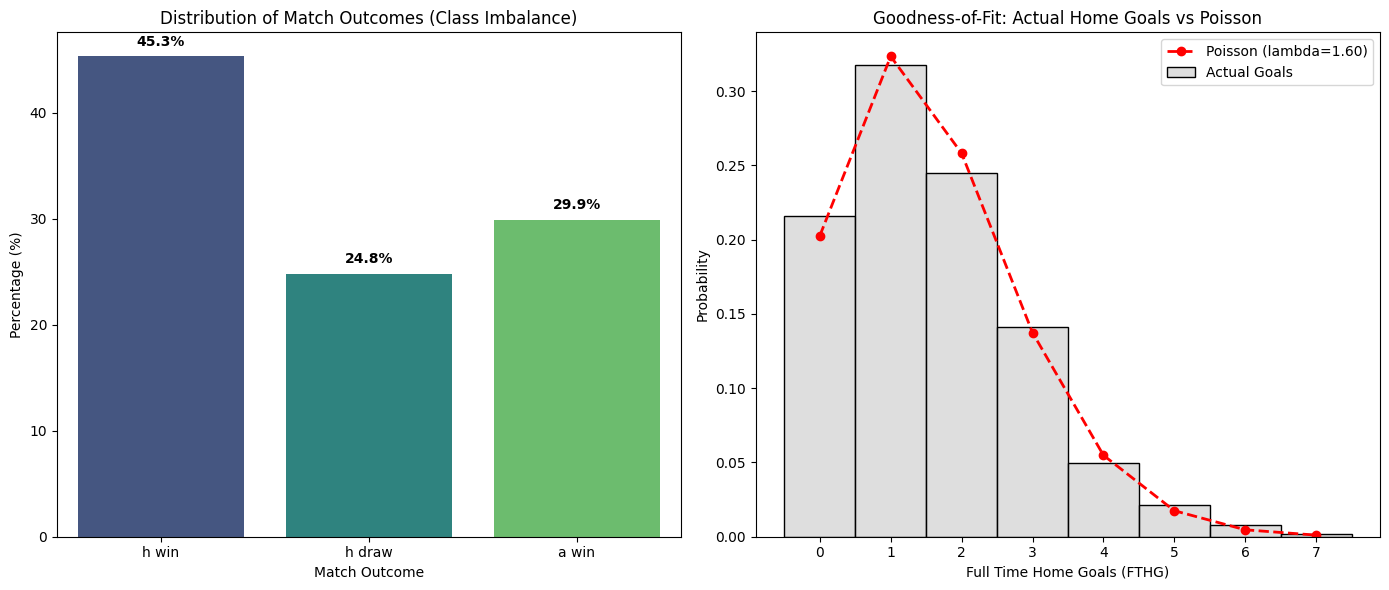

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

# Load the dataset
df = pd.read_csv('../data/turkey_final_bayesian_model.csv')

# Consistent color palette
color_home = '#1f77b4'
color_away = '#ff7f0e'
color_draw = '#cccccc'

# Create a figure with two subplots to evaluate both classification and regression targets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Evaluate classification targets for class imbalance
# Calculate the total occurrences of home wins, draws, and away wins
outcomes = ['h win', 'h draw', 'a win']
counts = df[outcomes].sum()
percentages = (counts / len(df)) * 100

# Plot the distribution of match outcomes
sns.barplot(x=outcomes, y=percentages, ax=axes[0], palette=[color_home, color_draw, color_away])
axes[0].set_title('Distribution of Match Outcomes (Class Imbalance)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Match Outcome')

# Add exact percentage labels to the top of each bar
for index, value in enumerate(percentages):
    axes[0].text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

# Evaluate regression targets for goodness-of-fit
# Compare the actual home goals distribution against a theoretical Poisson distribution
actual_home_goals = df['FTHG']
average_home_goals = actual_home_goals.mean()

# Plot the actual distribution of home goals as a density histogram
sns.histplot(actual_home_goals, bins=range(int(actual_home_goals.max()) + 2),
             stat='probability', discrete=True, color='#e2e8f0', ax=axes[1], label='Actual Goals')

# Generate the theoretical Poisson distribution using the dataset's average home goals
x_values = np.arange(0, int(actual_home_goals.max()) + 1)
poisson_probabilities = poisson.pmf(x_values, average_home_goals)

# Overlay the theoretical Poisson probabilities as a line plot
axes[1].plot(x_values, poisson_probabilities, marker='o', color='#ef4444',
             linestyle='dashed', linewidth=2, label=f'Poisson (lambda={average_home_goals:.2f})')

axes[1].set_title('Goodness-of-Fit: Actual Home Goals vs Poisson')
axes[1].set_xlabel('Full Time Home Goals (FTHG)')
axes[1].set_ylabel('Probability')
axes[1].legend()

# Apply tight layout to ensure labels do not overlap and display the plots
plt.tight_layout()
plt.show()

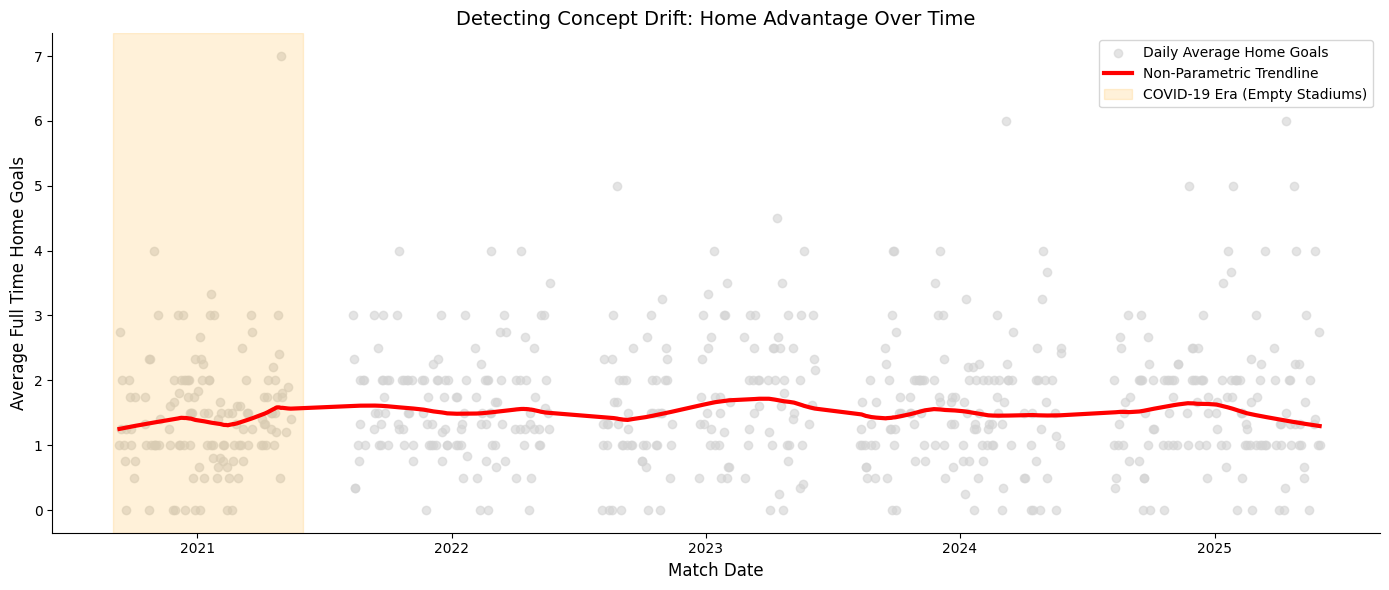

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

# Load the dataset and ensure chronological order
df = pd.read_csv('../data/turkey_final_bayesian_model.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Consistent color palette
color_home = '#1f77b4'

# Calculate the average home goals scored on each specific matchday
daily_goals = df.groupby('Date')['FTHG'].mean().reset_index()

# Convert dates to a numeric format required by the mathematical smoothing algorithm
x_numeric = mdates.date2num(daily_goals['Date'])
y_values = daily_goals['FTHG'].values

# Apply a non-parametric smoother (LOWESS) to find the true underlying trend
# The fraction parameter controls the window size of the kernel smoothing
smoothed_data = sm.nonparametric.lowess(y_values, x_numeric, frac=0.15)
smoothed_y = smoothed_data[:, 1]

# Set up the visualization canvas
plt.figure(figsize=(14, 6))

# Plot the raw, noisy daily averages lightly in the background
plt.scatter(
    daily_goals['Date'],
    y_values,
    color='lightgray',
    alpha=0.6,
    label='Daily Average Home Goals'
)

# Overlay the non-parametric spline/smooth curve to reveal long-term drift
plt.plot(
    daily_goals['Date'],
    smoothed_y,
    color=color_home,
    linewidth=3,
    label='Non-Parametric Trendline'
)

# Highlight the COVID-19 empty stadium era to visually check for concept drift
covid_start = pd.to_datetime('2020-09-01')
covid_end = pd.to_datetime('2021-06-01')
plt.axvspan(
    covid_start,
    covid_end,
    color='orange',
    alpha=0.15,
    label='COVID-19 Era (Empty Stadiums)'
)

# Format the chart to be clean and readable
plt.title('Detecting Concept Drift: Home Advantage Over Time', fontsize=14)
plt.xlabel('Match Date', fontsize=12)
plt.ylabel('Average Full Time Home Goals', fontsize=12)
plt.legend(loc='upper right')

# Remove heavy borders to maximize data-to-ink ratio
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Code logic to apply the binary feature if the visual drift is confirmed
df['is_covid_era'] = np.where((df['Date'] >= covid_start) & (df['Date'] <= covid_end), 1, 0)

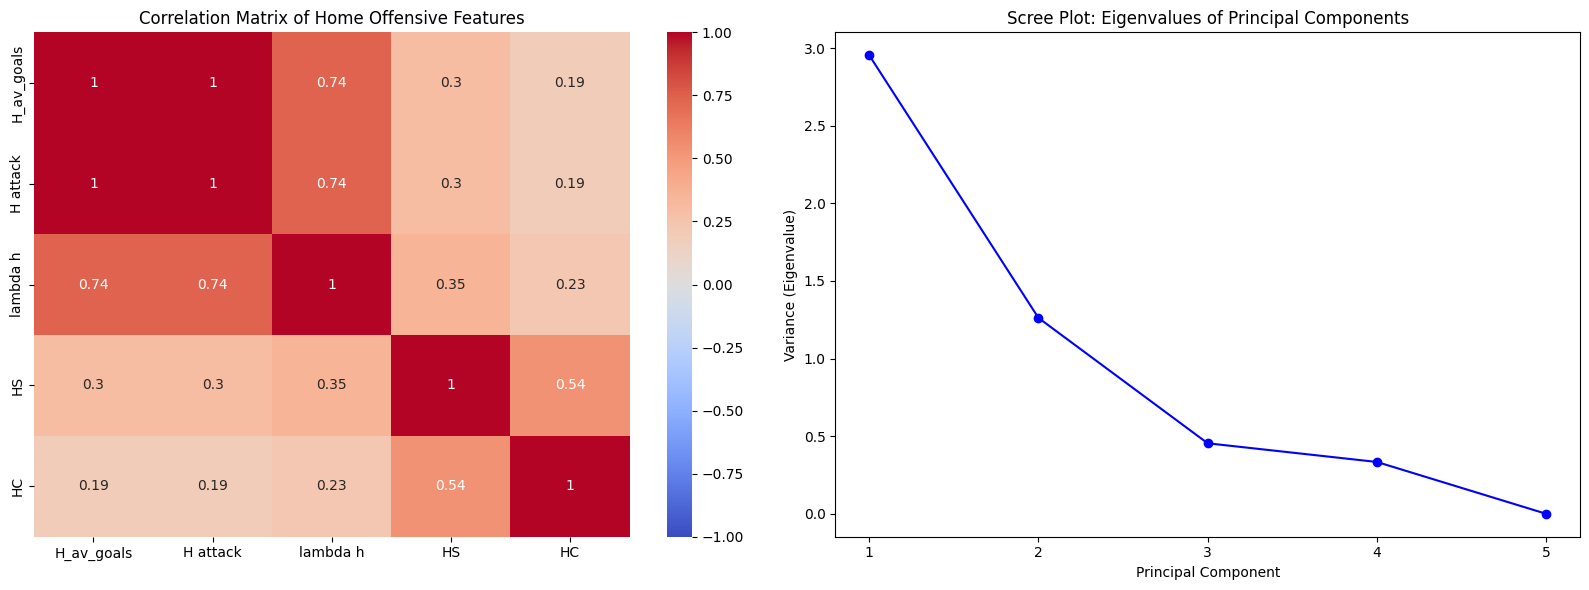

Factor Loadings for the First Principal Component:
H attack      0.539395
H_av_goals    0.539395
lambda h      0.497021
HS            0.327573
HC            0.252532
dtype: float64


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Isolate the home offensive features that are likely highly correlated
offensive_features = ['H_av_goals', 'H attack', 'lambda h', 'HS', 'HC']
pca_data = df[offensive_features].dropna()

# Standardize the data to have mean 0 and variance 1
scaler = StandardScaler()
scaled_features = scaler.fit_transform(pca_data)

# Fit the Principal Component Analysis
pca = PCA()
pca.fit(scaled_features)

# Set up a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Correlation Heatmap
correlation_matrix = pca_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix of Home Offensive Features')

# Subplot 2: Scree Plot
axes[1].plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker='o', color='blue')
axes[1].set_title('Scree Plot: Eigenvalues of Principal Components')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance (Eigenvalue)')
axes[1].set_xticks(range(1, len(offensive_features) + 1))

plt.tight_layout()
plt.show()

# Extract and display the factor loadings for the first principal component
first_component_loadings = pd.Series(pca.components_[0], index=offensive_features)
print("Factor Loadings for the First Principal Component:")
print(first_component_loadings.sort_values(ascending=False))

# Project the original data down into the new 1-dimensional subspace
df['home_offensive_threat'] = np.nan
df.loc[pca_data.index, 'home_offensive_threat'] = pca.transform(scaled_features)[:, 0]

Tuning hyperparameters using Time-Series Cross Validation...

Offline Evaluation Results
Baseline Accuracy:        0.4796
Baseline F1 Score:        0.2161

Default Model Accuracy:   0.4932
Default Model F1 Score:   0.4290

Tuned Model Accuracy:     0.4768
Tuned Model F1 Score:     0.4578

Best Hyperparameters Found:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

        Draw       0.25      0.37      0.30        86
    Home Win       0.63      0.55      0.59       176
    Away Win       0.55      0.44      0.49       105

    accuracy                           0.48       367
   macro avg       0.48      0.45      0.46       367
weighted avg       0.52      0.48      0.49       367



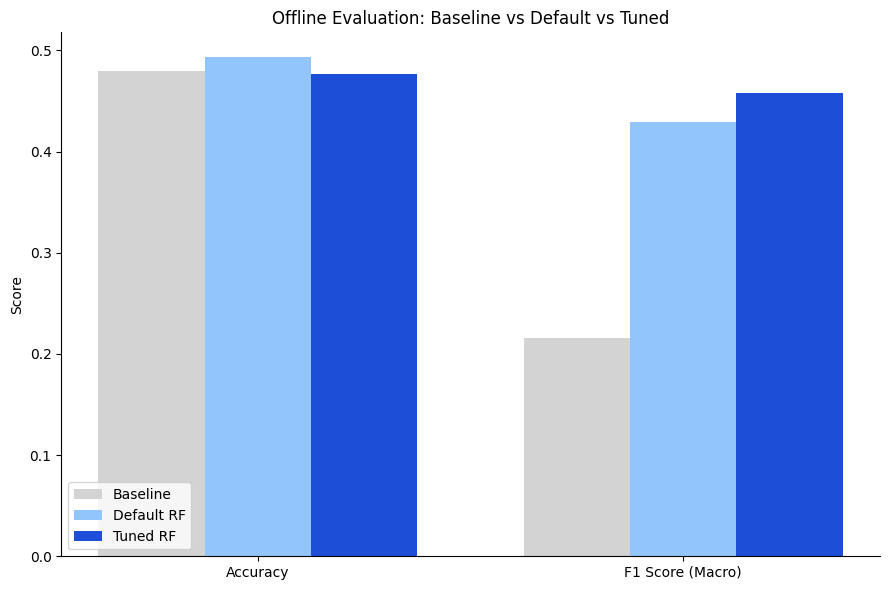

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Create a single multi-class target variable: 1 for Home Win, 0 for Draw, 2 for Away Win
df['target'] = df[['h draw', 'h win', 'a win']].apply(
    lambda x: 1 if x['h win'] == 1 else (2 if x['a win'] == 1 else 0), axis=1
)

# Drop post-match statistics and direct target identifiers to prevent data leakage
# Crucially, we drop 'h p' and 'a p' which previously leaked the match results
columns_to_drop = [
    'FTHG', 'FTAG', 'HC', 'AC', 'HY', 'AY', 'HS', 'AS', 'gd',
    'h win', 'h draw', 'a win', 'h p', 'a p',
    'H_av_goals', 'H attack', 'lambda h'
]
model_df = df.drop(columns=columns_to_drop, errors='ignore')

# Sort values chronologically to ensure strict time-based splitting
model_df = model_df.sort_values(by='Date').reset_index(drop=True)

# Select the features available prior to kickoff
# We include our engineered features and the Bayesian probabilities
feature_cols = [
    'home_offensive_threat', 'A attack', 'H def', 'A def',
    'h win rt', 'a win rt', 'is_covid_era',
    'Post_P(h)', 'Post_P(d)', 'Post_P(A)'
]

# Drop any potential NaNs generated by PCA or earlier window functions
model_df = model_df.dropna(subset=feature_cols + ['target'])

X = model_df[feature_cols]
y = model_df['target']

# Perform a chronological split using 80% of the data for training and 20% for testing
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Initialize a Zero-Rule baseline model that predicts the most frequent class (Home Win)
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions, average='macro')

# Train a default Random Forest model using balanced class weights
default_ml_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
default_ml_model.fit(X_train, y_train)
default_predictions = default_ml_model.predict(X_test)

default_accuracy = accuracy_score(y_test, default_predictions)
default_f1 = f1_score(y_test, default_predictions, average='macro')

# Define the hyperparameter grid for tuning
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Use TimeSeriesSplit to prevent data leakage during cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Initialize RandomizedSearchCV to find the best hyperparameters
print("Tuning hyperparameters using Time-Series Cross Validation...")
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)
tuned_ml_model = rf_random.best_estimator_
tuned_predictions = tuned_ml_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_predictions)
tuned_f1 = f1_score(y_test, tuned_predictions, average='macro')

print("\nOffline Evaluation Results")
print(f"Baseline Accuracy:        {baseline_accuracy:.4f}")
print(f"Baseline F1 Score:        {baseline_f1:.4f}\n")
print(f"Default Model Accuracy:   {default_accuracy:.4f}")
print(f"Default Model F1 Score:   {default_f1:.4f}\n")
print(f"Tuned Model Accuracy:     {tuned_accuracy:.4f}")
print(f"Tuned Model F1 Score:     {tuned_f1:.4f}\n")
print("Best Hyperparameters Found:")
print(rf_random.best_params_)
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, tuned_predictions, target_names=['Draw', 'Home Win', 'Away Win']))

# Visualize the performance comparison of all three models
fig, ax = plt.subplots(figsize=(9, 6))
metrics = ['Accuracy', 'F1 Score (Macro)']
baseline_scores = [baseline_accuracy, baseline_f1]
default_scores = [default_accuracy, default_f1]
tuned_scores = [tuned_accuracy, tuned_f1]

x_indices = np.arange(len(metrics))
bar_width = 0.25

ax.bar(x_indices - bar_width, baseline_scores, bar_width, label='Baseline', color='lightgray')
ax.bar(x_indices, default_scores, bar_width, label='Default RF', color='#93c5fd')
ax.bar(x_indices + bar_width, tuned_scores, bar_width, label='Tuned RF', color='#1d4ed8')

ax.set_ylabel('Score')
ax.set_title('Offline Evaluation: Baseline vs Default vs Tuned')
ax.set_xticks(x_indices)
ax.set_xticklabels(metrics)
ax.legend(loc='lower left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Feature Importances:
Post_P(h): 0.1707
home_offensive_threat: 0.1460
Post_P(A): 0.1244
a win rt: 0.1053
h win rt: 0.1046
Post_P(d): 0.1012
A attack: 0.0820
A def: 0.0809
H def: 0.0773
is_covid_era: 0.0075


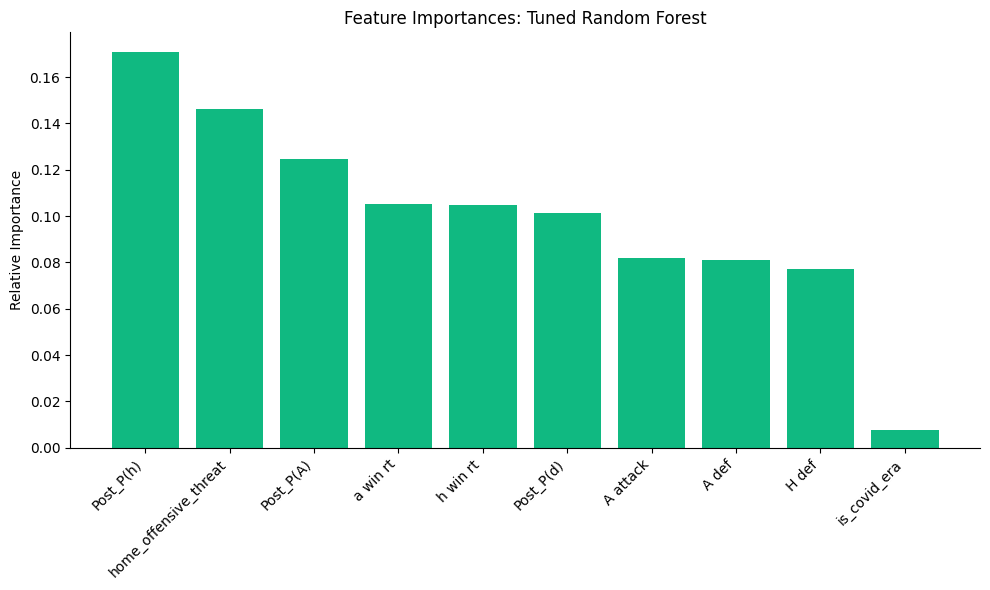

In [10]:
# Extract feature importances from the tuned model to understand what drives predictions
importances = tuned_ml_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = importances[indices]

# Print the exact importance values to the console
print("\nFeature Importances:")
for i, feature in enumerate(sorted_features):
    print(f"{feature}: {sorted_importances[i]:.4f}")

# Visualize the feature importances as a bar chart for easy interpretation
fig_imp, ax_imp = plt.subplots(figsize=(10, 6))

ax_imp.bar(range(len(importances)), sorted_importances, color='#10b981', align='center')
ax_imp.set_xticks(range(len(importances)))
ax_imp.set_xticklabels(sorted_features, rotation=45, ha='right')
ax_imp.set_title('Feature Importances: Tuned Random Forest')
ax_imp.set_ylabel('Relative Importance')

ax_imp.spines['top'].set_visible(False)
ax_imp.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load and prepare data chronologically
df = pd.read_csv('../data/turkey_final_bayesian_model.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Define the COVID era for context in later analysis
covid_start = pd.to_datetime('2020-09-01')
covid_end = pd.to_datetime('2021-06-01')
df['is_covid_era'] = np.where((df['Date'] >= covid_start) & (df['Date'] <= covid_end), 1, 0)

# Global styling configuration for all interactive plots
plotly_theme = 'plotly_white'
color_home = '#1f77b4'
color_away = '#ff7f0e'
color_draw = '#cccccc'
color_neutral = '#10b981'

# Temporal Integrity and Data Leakage Check
team_name = 'Fenerbahce'
team_df = df[df['HomeTeam'] == team_name].copy()
team_df['past_home_wins'] = team_df['h win'].shift(1).cumsum().fillna(0)
team_df['past_home_games'] = team_df['h win'].shift(1).expanding().count().fillna(0)
team_df['manual_h_win_rt'] = (team_df['past_home_wins'] / team_df['past_home_games']) * 100
team_df['manual_h_win_rt'] = team_df['manual_h_win_rt'].fillna(0)

# Calculate rolling discrepancy to spot data leakage
team_df['leakage_difference'] = team_df['h win rt'] - team_df['manual_h_win_rt']

# Build interactive line chart with narrative hover tooltips
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=team_df['Date'],
    y=team_df['h win rt'],
    mode='lines+markers',
    name='Engineered Feature',
    marker_color=color_home,
    customdata=team_df['leakage_difference'],
    hovertemplate='<b>Date:</b> %{x}<br><b>Dataset Win Rate:</b> %{y:.1f}%<br><b>Leakage Diff:</b> %{customdata:.2f}%<extra></extra>'
))
fig1.add_trace(go.Scatter(
    x=team_df['Date'],
    y=team_df['manual_h_win_rt'],
    mode='lines',
    name='Calculated Past Math',
    line=dict(dash='dash', color='gray'),
    hovertemplate='<b>Strictly Historical Win Rate:</b> %{y:.1f}%<extra></extra>'
))
fig1.update_layout(
    title=f'Data Leakage Verification: {team_name}',
    hovermode='x unified',
    yaxis_title='Historical Win Rate (%)',
    template=plotly_theme
)
fig1.show()

# Target Distribution and Poisson Goodness-of-Fit Checks
outcomes = ['h win', 'h draw', 'a win']
friendly_names = ['Home Win', 'Draw', 'Away Win']
counts = df[outcomes].sum()
percentages = (counts / len(df)) * 100

fig2 = make_subplots(rows=1, cols=2, subplot_titles=('Class Imbalance (Why we need class weights)', 'Poisson Math vs Reality (Zero-Inflation)'))

# Add bar chart with semantic colors and descriptive hovers
fig2.add_trace(go.Bar(
    x=friendly_names,
    y=percentages,
    name='Outcome Frequency',
    text=[f"{val:.1f}%" for val in percentages],
    textposition='auto',
    marker_color=[color_home, color_draw, color_away],
    hovertemplate='<b>%{x}</b> occurred in %{y:.1f}% of all historical matches.<extra></extra>'
), row=1, col=1)

# Convert probabilities to percentages for readable tooltips
actual_goals = df['FTHG'].value_counts(normalize=True).sort_index() * 100
avg_goals = df['FTHG'].mean()
x_val = np.arange(0, int(df['FTHG'].max()) + 1)
poisson_prob = poisson.pmf(x_val, avg_goals) * 100

fig2.add_trace(go.Bar(
    x=actual_goals.index,
    y=actual_goals.values,
    name='Actual Goals',
    marker_color='#e2e8f0',
    hovertemplate='<b>%{x} Goals</b> occurred in %{y:.1f}% of matches.<extra></extra>'
), row=1, col=2)

fig2.add_trace(go.Scatter(
    x=x_val,
    y=poisson_prob,
    mode='lines+markers',
    name=f'Poisson Expected',
    line=dict(color='#ef4444', width=3),
    hovertemplate='<b>Poisson expects %{x} goals</b> to happen %{y:.1f}% of the time.<extra></extra>'
), row=1, col=2)

# Add an active annotation to highlight the exact insight the user needs to see
fig2.add_annotation(
    x=0, y=actual_goals[0],
    text="Reality > Math<br>(Teams play for 0-0)",
    showarrow=True, arrowhead=1, ax=40, ay=-40,
    font=dict(color="#ef4444", size=10),
    row=1, col=2
)

fig2.update_layout(title='Distribution & Assumptions', showlegend=False, template=plotly_theme)
fig2.show()

# Concept Drift Detection with Interactive Timeline Slider
daily_goals = df.groupby('Date')['FTHG'].mean().reset_index()
x_numeric = pd.to_numeric(daily_goals['Date'])
smoothed_data = sm.nonparametric.lowess(daily_goals['FTHG'], x_numeric, frac=0.15)

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=daily_goals['Date'],
    y=daily_goals['FTHG'],
    mode='markers',
    name='Daily Avg',
    opacity=0.3,
    marker=dict(color='gray', size=5),
    hovertemplate='<b>%{x}</b><br>Average Goals: %{y:.2f}<extra></extra>'
))
fig3.add_trace(go.Scatter(
    x=daily_goals['Date'],
    y=smoothed_data[:, 1],
    mode='lines',
    name='Underlying Trend',
    line=dict(color=color_home, width=4),
    hovertemplate='<b>Smoothed Trend:</b> %{y:.2f} goals<extra></extra>'
))

# Configure range slider for "Scrollytelling"
fig3.update_layout(
    title='Concept Drift: The Impact of Empty Stadiums',
    xaxis=dict(rangeslider=dict(visible=True), type="date", title='Drag slider below to zoom'),
    yaxis_title='Average Home Goals',
    template=plotly_theme
)
fig3.add_vrect(
    x0=covid_start, x1=covid_end,
    fillcolor="orange", opacity=0.15, layer="below", line_width=0,
    annotation_text="COVID-19 Era (Drift)", annotation_position="top left"
)

fig3.add_annotation(
    x='2021-01-15', y=1.35,
    text="Significant drop in<br>home attacking form",
    showarrow=True, arrowhead=1, ax=0, ay=45,
    font=dict(color="#ef4444", size=11)
)

fig3.show()

# Principal Component Analysis and Multicollinearity Check
offensive_features = ['H_av_goals', 'H attack', 'lambda h', 'HS', 'HC']
pca_data = df[offensive_features].dropna()
corr_matrix = pca_data.corr()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(pca_data)
pca = PCA()
pca.fit(scaled_features)

# Extract factor loadings for the first principal component to reify the metric
first_component_loadings = pd.Series(pca.components_[0], index=offensive_features)
loadings_sorted = first_component_loadings.sort_values(ascending=True)

fig4 = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Feature Multicollinearity', 'PCA Scree Plot', 'PC1 Factor Loadings'),
    horizontal_spacing=0.1
)

# Format heatmap tooltip
fig4.add_trace(go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    colorscale='RdBu', zmin=-1, zmax=1,
    hovertemplate='Correlation between %{x} and %{y}: <b>%{z:.2f}</b><extra></extra>'
), row=1, col=1)

# Format scree plot tooltip
fig4.add_trace(go.Scatter(
    x=list(range(1, 6)),
    y=pca.explained_variance_,
    mode='lines+markers',
    line=dict(color=color_neutral, width=3),
    hovertemplate='<b>Component %{x}</b> captures %{y:.2f} units of variance.<extra></extra>'
), row=1, col=2)

# Format factor loadings bar chart
fig4.add_trace(go.Bar(
    x=loadings_sorted.values,
    y=loadings_sorted.index,
    orientation='h',
    marker_color=color_home,
    hovertemplate='<b>%{y}</b> loading: %{x:.3f}<extra></extra>'
), row=1, col=3)

# Add active annotation pointing out the perfect collinearity in the heatmap
fig4.add_annotation(
    x='H_av_goals', y='H attack',
    text="Perfect Collinearity (1.0)",
    showarrow=True, arrowhead=1, ax=40, ay=-40,
    font=dict(color="#ef4444", size=10),
    row=1, col=1
)

# Add active annotation pointing out the elbow in the scree plot
fig4.add_annotation(
    x=2, y=pca.explained_variance_[1],
    text="The 'Elbow'<br>Keep PC1",
    showarrow=True, arrowhead=1, ax=30, ay=30,
    font=dict(color=color_home, size=10),
    row=1, col=2
)

fig4.update_layout(
    title='Dimensionality Reduction: Solving Multicollinearity',
    template=plotly_theme,
    showlegend=False
)
fig4.show()

# Map the principal component back to the dataframe
df['home_offensive_threat'] = np.nan
df.loc[pca_data.index, 'home_offensive_threat'] = pca.transform(scaled_features)[:, 0]

# Model Evaluation and Feature Importance Extraction
df['target'] = df[['h draw', 'h win', 'a win']].apply(lambda x: 1 if x['h win'] == 1 else (2 if x['a win'] == 1 else 0), axis=1)

columns_to_drop = ['FTHG', 'FTAG', 'HC', 'AC', 'HY', 'AY', 'HS', 'AS', 'gd', 'h win', 'h draw', 'a win', 'h p', 'a p', 'H_av_goals', 'H attack', 'lambda h']
model_df = df.drop(columns=columns_to_drop, errors='ignore')

feature_cols = ['home_offensive_threat', 'A attack', 'H def', 'A def', 'h win rt', 'a win rt', 'is_covid_era', 'Post_P(h)', 'Post_P(d)', 'Post_P(A)']
model_df = model_df.dropna(subset=feature_cols + ['target'])

X = model_df[feature_cols]
y = model_df['target']
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
base_preds = baseline.predict(X_test)
base_acc, base_f1 = accuracy_score(y_test, base_preds), f1_score(y_test, base_preds, average='macro')

rf_default = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced').fit(X_train, y_train)
def_preds = rf_default.predict(X_test)
def_acc, def_f1 = accuracy_score(y_test, def_preds), f1_score(y_test, def_preds, average='macro')

# Full hyperparameter grid matching the exploratory analysis
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
tscv = TimeSeriesSplit(n_splits=3)
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)
rf_random.fit(X_train, y_train)
tuned_model = rf_random.best_estimator_
tuned_preds = tuned_model.predict(X_test)
tuned_acc, tuned_f1 = accuracy_score(y_test, tuned_preds), f1_score(y_test, tuned_preds, average='macro')

models = ['Baseline', 'Default RF', 'Tuned RF']
acc_scores = [base_acc, def_acc, tuned_acc]
f1_scores = [base_f1, def_f1, tuned_f1]

# Split model evaluation and feature importance into two clean figures
# Figure 5: Model Performance Comparison
fig5 = go.Figure()

fig5.add_trace(go.Bar(
    name='Accuracy', x=models, y=acc_scores, marker_color='#e2e8f0',
    hovertemplate='<b>%{x}</b><br>Accuracy: %{y:.3f} (Overall correctness)<extra></extra>'
))

fig5.add_trace(go.Bar(
    name='F1 Score', x=models, y=f1_scores, marker_color=color_home,
    hovertemplate='<b>%{x}</b><br>F1 Score: %{y:.3f} (Ability to find upsets/draws)<extra></extra>'
))

fig5.add_annotation(
    x='Tuned RF', y=tuned_f1,
    text="F1 Score Peaks!<br>Model sacrifices 'safe' Home<br>Wins to find difficult Draws.",
    showarrow=True, arrowhead=1, ax=-140, ay=-40,
    font=dict(color=color_home, size=11)
)

fig5.update_layout(
    title='Model Performance: The Accuracy vs F1 Trade-off',
    barmode='group',
    yaxis_title='Score',
    template=plotly_theme,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig5.show()

# Figure 6: Feature Importance — What Drives the Model?
importances = tuned_model.feature_importances_
indices = np.argsort(importances)
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = importances[indices]

# Pre-attentive color: highlight the dominant feature, mute the rest
bar_colors = [color_home if i == len(sorted_importances) - 1 else '#cbd5e1' for i in range(len(sorted_importances))]

fig6 = go.Figure()

fig6.add_trace(go.Bar(
    x=sorted_importances,
    y=sorted_features,
    orientation='h',
    marker_color=bar_colors,
    name='Importance Weight',
    hovertemplate='<b>%{y}</b> provides %{x:.3f} importance weight.<extra></extra>'
))

fig6.add_annotation(
    x=sorted_importances[-1], y=sorted_features[-1],
    text="Engineered math<br>dominates the model",
    showarrow=True, arrowhead=1, ax=0, ay=-40,
    font=dict(color=color_home, size=12, weight='bold')
)

fig6.update_layout(
    title='What Drives the Model?',
    xaxis_title='Relative Importance',
    template=plotly_theme,
    showlegend=False,
    margin=dict(l=160)
)
fig6.show()

FileNotFoundError: [Errno 2] No such file or directory: 'turkey_final_bayesian_model.csv'